# Rzeczywista transformata Fouriera (DFT)

Rzeczywista transformata Fouriera powstaje z interpolacji trygonometrycznej
(szeregiem Fouriera) poprzez połączenie członów sinusowych i kosinusowych
o tej samej częstotliwości. Sygnał można odtworzyć (zrekonstruować) z jego
widma za pomocą wzoru:

$$x[n] = \sum_{k=0}^{N/2}\big[X_r[k]\cos(2\pi kn/N) - X_i[k]\sin(2\pi kn/N)\big]$$

**Amplitudowe spektrum:**

$$A[k] = \sqrt{X_r[k]^2 + X_i[k]^2} = |X[k]|$$

W wystarczającej liczbie próbek szczyty spektrum wskazują częstotliwości składowych sygnału.

### Definicje

- **Częstotliwość Nyquista:** $f_N = f_s/2$ — najwyższa częstotliwość, którą można poprawnie odtworzyć.
- **Rozdzielczość częstotliwościowa:** $\Delta f = f_s/N = 1/T$.
- **Okno (windowing):** skończony przedział obserwacji powoduje rozmycie widma.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

def real_DFT(y):
    """Rzeczywista transformata Fouriera — zwraca połowę spektrum."""
    n = len(y)
    X = np.fft.fft(y)
    m = np.abs(X) / n
    m[1:n//2] *= 2  # podwójna amplituda dla wewn. współczynników
    m_real = m[:n//2 + 1]
    f = np.arange(n//2 + 1)
    return f, m_real

In [2]:
# Sanity-check: sinusoida o amplitudzie jednostkowej powinna dac w widmie
# pojedynczy pik o amplitudzie DOKLADNIE 1 (dzieki normalizacji /n i podwojeniu
# wewnetrznych binow w real_DFT powyzej). To zamienia weryfikacje "na oko"
# (jak w komorce z analiza widma nizej) na sprawdzalny fakt liczbowy.
t_test = np.arange(0, 1, 1/100)  # fs=100 Hz, dokladnie 1 s -> zero leakage dla f=5 Hz
_, a_test = real_DFT(np.sin(2*np.pi*5*t_test))
pik = a_test[np.argmax(a_test)]
print(f"Sanity-check: amplituda piku dla czystej sinusoidy = {pik:.6f} (oczekiwane: 1.0)")
assert abs(pik - 1.0) < 1e-9, "real_DFT nie zwraca oczekiwanej amplitudy dla czystej sinusoidy!"

Sanity-check: amplituda piku dla czystej sinusoidy = 1.000000 (oczekiwane: 1.0)


## Przykład: Sygnał złożony z dwóch sinusoid

Częstotliwości: $f_1=3$ Hz, $f_2=10$ Hz, próbkowanie $f_s=100$ kHz.

In [3]:
fs = 100e3  # częstotliwość próbkowania 100 kHz
t = np.arange(0, 3, 1/fs)
f_signal = lambda t: 2*np.sin(2*np.pi*3*t) + 0.4*np.sin(2*np.pi*10*t)
y = f_signal(t)

# FFT
f_axis, m_real = real_DFT(y)

print(f'Liczba próbek: {len(y)}')
print(f'Częstotliwość Nyquista: {fs/2:.0f} Hz')
print(f'Rozdzielczość: {fs/len(y):.4f} Hz')

Liczba próbek: 300000
Częstotliwość Nyquista: 50000 Hz
Rozdzielczość: 0.3333 Hz


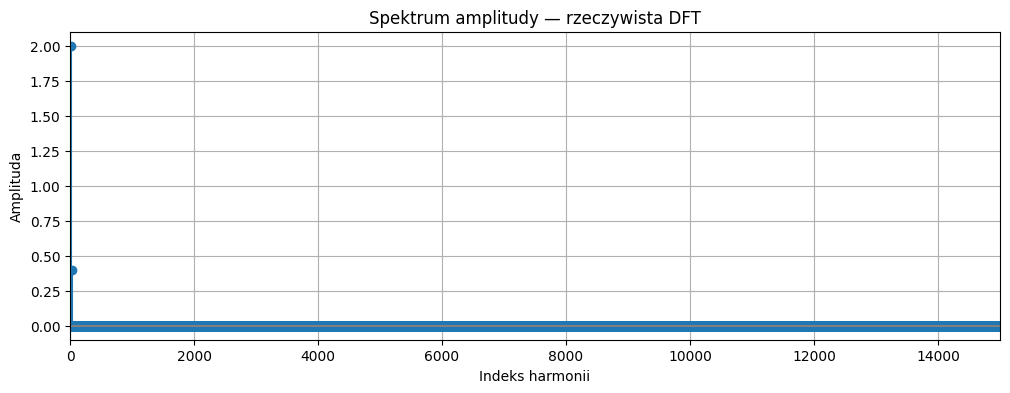

In [4]:
plt.figure(figsize=(12, 4))
plt.stem(f_axis, m_real, basefmt='grey')
plt.xlabel('Indeks harmonii')
plt.ylabel('Amplituda')
plt.title('Spektrum amplitudy — rzeczywista DFT')
plt.grid(True)
plt.xlim(0, max(f_axis)*0.1)  # zoom in on low frequencies
plt.show()

### Analiza widma

Szczyty widma pojawiają się przy indeksach odpowiadających częstotliwościom 3 Hz i 10 Hz. Amplituda składowej 3 Hz jest pięciokrotnie większa od amplitudy składowej 10 Hz, co odzwierciedla proporcje $2 : 0.4$ w definicji sygnału.

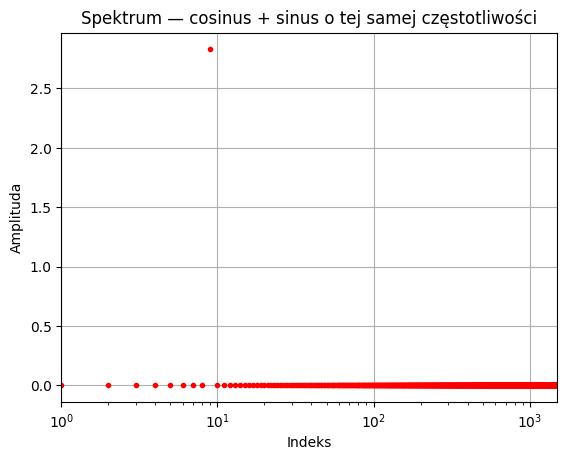

In [5]:
# Kosinus + sinus o tej samej częstotliwości
f2 = lambda t: 2*np.cos(6*np.pi*t) + 2*np.sin(6*np.pi*t)  # f=3 Hz
y2 = f2(t)
f_axis2, m2 = real_DFT(y2)

plt.semilogx(m2, 'or', markersize=3)
plt.xlabel('Indeks')
plt.ylabel('Amplituda')
plt.title('Spektrum — cosinus + sinus o tej samej częstotliwości')
plt.grid(True)
plt.xlim(1, len(m2)*0.01)  # skala log-x nie akceptuje 0 jako dolnej granicy
plt.show()

### Efekt okna i rozdzielczość

| Parametr | Wartość |
|----------|--------|
| $f_s$ | $100\,$kHz |
| $f_N = f_s/2$ | $50\,$kHz |
| $\Delta f = f_s/N$ | $\approx 0.333\,$Hz |
| Czas obserwacji $T$ | $3\,$s |

Skończony czas obserwacji działa jak okno prostokątne, co powoduje rozmycie widma (spectral leakage).

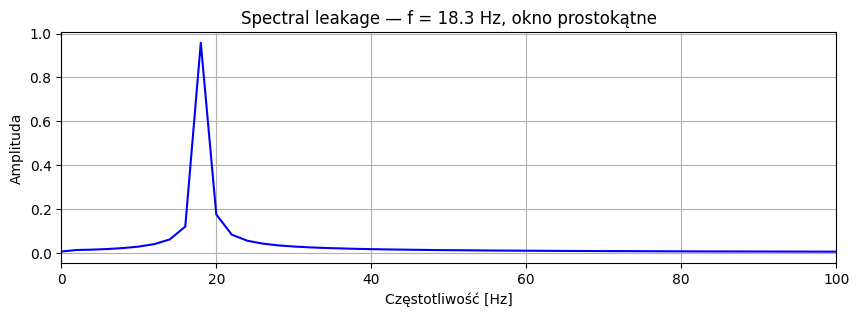

In [6]:
# Wizualizacja spectral leakage
fs2 = 1e3  # 1 kHz — niższe próbkowanie dla lepszego widma
t2 = np.arange(0, 0.5, 1/fs2)
y3 = np.sin(2*np.pi*18.3*t2)  # częstotliwość nierezonansowa

_, m_leak = real_DFT(y3)
freq = np.arange(len(m_leak)) * fs2 / len(y3)

plt.figure(figsize=(10, 3))
plt.plot(freq, m_leak, 'b-')
plt.xlabel('Częstotliwość [Hz]')
plt.ylabel('Amplituda')
plt.title('Spectral leakage — f = 18.3 Hz, okno prostokątne')
plt.grid(True)
plt.xlim(0, 100)
plt.show()

## Ćwiczenie

| Sygnał | Zadanie |
|--------|--------|
| $x(t)=\cos(2\pi\cdot 7\,t)+0.5\cos(2\pi\cdot 23\,t)$ | Znajdź szczyty widma, oceń amplitudy |
| $x(t)=3\sin(2\pi\cdot 15\,t)\cdot\cos(2\pi\cdot 150\,t)$ | Zidentyfikuj częstotliwości boczne |
| Sygnał szumu + ton | Dodaj szum Gaussian, oceń SNR w domenie częstotliwości |

Dla każdego sygnału: przeanalizuj widmo, oceń rozdzielczość, omów efekt okna.